# LightGBM Model

## Imports

In [1]:
import sys; sys.path.append("..")

from src.features import build_holiday_lookup
from src.training import build_features, evaluate_lgbm, CATEGORICAL
from src.evaluate import score_table, rmsle
from src.models import train_lgbm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

/Users/jordan/github/favorita-demand-forecasting/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train = pd.read_parquet("../data/processed/train.parquet")
stores = pd.read_parquet("../data/processed/stores.parquet")
oil = pd.read_parquet("../data/processed/oil.parquet")
holidays = pd.read_parquet("../data/processed/holidays.parquet")

## Validate Feature Creation Pipeline

In [3]:
national, local = build_holiday_lookup(holidays)
feats = build_features(train.copy(), stores, oil, national, local)

print("Shape:", feats.shape)
print("\nColumns:\n", list(feats.columns))
feats.head(20)

Shape: (3000888, 27)

Columns:
 ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type', 'cluster', 'dcoilwtico', 'oil_roll_14', 'dow', 'month', 'day', 'year', 'payday', 'is_holiday', 'sales_lag_16', 'sales_lag_21', 'sales_lag_28', 'roll_mean_7', 'roll_std_7', 'roll_mean_14', 'roll_std_14', 'roll_mean_30', 'roll_std_30']


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,...,is_holiday,sales_lag_16,sales_lag_21,sales_lag_28,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14,roll_mean_30,roll_std_30
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1782,1782,2013-01-02,1,AUTOMOTIVE,2.0,0,Quito,Pichincha,D,13,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3564,3564,2013-01-03,1,AUTOMOTIVE,3.0,0,Quito,Pichincha,D,13,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5346,5346,2013-01-04,1,AUTOMOTIVE,3.0,0,Quito,Pichincha,D,13,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7128,7128,2013-01-05,1,AUTOMOTIVE,5.0,0,Quito,Pichincha,D,13,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8910,8910,2013-01-06,1,AUTOMOTIVE,2.0,0,Quito,Pichincha,D,13,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10692,10692,2013-01-07,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12474,12474,2013-01-08,1,AUTOMOTIVE,2.0,0,Quito,Pichincha,D,13,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14256,14256,2013-01-09,1,AUTOMOTIVE,2.0,0,Quito,Pichincha,D,13,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16038,16038,2013-01-10,1,AUTOMOTIVE,2.0,0,Quito,Pichincha,D,13,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
mask = (feats["store_nbr"] == 1).to_numpy() & (feats["family"] == "PRODUCE").to_numpy()
s = feats[mask].sort_values("date").reset_index(drop=True)

print("Sales at row 14:", s.loc[14, "sales"])
print("lag_16 at row 30:", s.loc[30, "sales_lag_16"])

assert s.loc[30, "sales_lag_16"] == s.loc[14, "sales"], "LAG MISALIGNED - Leak Risk"
print("lag_16 correctly references 16 rows back.")

Sales at row 14: 0.0
lag_16 at row 30: 0.0
lag_16 correctly references 16 rows back.


In [5]:
firsts = feats.sort_values("date").groupby(["store_nbr", "family"], observed=True).head(1)

print("First-row lag_16 all NaN?", firsts["sales_lag_16"].isna().all())
assert firsts["sales_lag_16"].isna().all(), "LEAK: lgas crossing series boundaries."

First-row lag_16 all NaN? True


In [6]:
for c in ["family", "city", "state", "type", "cluster"]:
    if c in feats.columns:
        print(f"{c}: {feats[c].dtype}")

print(feats.select_dtypes(include="object").columns.tolist()) # should be empty

family: category
city: category
state: category
type: category
cluster: int8
[]


In [7]:
drop = {"id", "date", "sales", "store_nbr"}
feature_cols = [c for c in feats.columns if c not in drop]
print("Features going to LightGBM:\n", feature_cols)

nan_pct = feats[feature_cols].isna().mean().sort_values(ascending=False)
print("\nNaN % by feature:\n", (nan_pct[nan_pct>0]*100).round(1))

Features going to LightGBM:
 ['family', 'onpromotion', 'city', 'state', 'type', 'cluster', 'dcoilwtico', 'oil_roll_14', 'dow', 'month', 'day', 'year', 'payday', 'is_holiday', 'sales_lag_16', 'sales_lag_21', 'sales_lag_28', 'roll_mean_7', 'roll_std_7', 'roll_mean_14', 'roll_std_14', 'roll_mean_30', 'roll_std_30']

NaN % by feature:
 dcoilwtico      28.6
oil_roll_14     28.6
roll_std_30      2.7
roll_mean_30     2.7
roll_std_14      1.7
roll_mean_14     1.7
sales_lag_28     1.7
roll_std_7       1.3
roll_mean_7      1.3
sales_lag_21     1.2
sales_lag_16     1.0
dtype: float64


## TEST: Train Single Fold

In [8]:
lgbm_preds = evaluate_lgbm(train, stores, oil, holidays, params={"num_boost_round": 50})
print(lgbm_preds.shape)
print(lgbm_preds.head())
print("\nNulls in predictions?", lgbm_preds.y_pred.isna().sum())
print("Any negative predictions?", (lgbm_preds.y_pred < 0).sum())
print("y_pred range:", lgbm_preds.y_pred.min(), "-", lgbm_preds.y_pred.max())

(114048, 6)
   store_nbr      family       date  y_true    y_pred  fold
0          1  AUTOMOTIVE 2017-06-13     5.0  2.740517     0
1          1  AUTOMOTIVE 2017-06-14     5.0  3.039113     0
2          1  AUTOMOTIVE 2017-06-15     3.0  2.808556     0
3          1  AUTOMOTIVE 2017-06-16     4.0  2.693902     0
4          1  AUTOMOTIVE 2017-06-17     3.0  3.661100     0

Nulls in predictions? 0
Any negative predictions? 0
y_pred range: 0.2921800062074796 - 5351.449018154668


## Train and Evaluate LightGBM 

In [9]:
lgbm_preds = evaluate_lgbm(train, stores, oil, holidays)
lgbm_overall, lgbm_family = score_table(lgbm_preds, "lightgbm")

/Users/jordan/github/favorita-demand-forecasting/notebooks/../src/evaluate.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_family = (preds.groupby("family", observed=True).apply(lambda g: pd.Series({


### Compare all model results (baseline, trained)

In [10]:
baseline_scores = pd.read_csv("../outputs/results/baseline_scores.csv")
family_scores = pd.read_csv("../outputs/results/baseline_scores_by_family.csv")

results = pd.concat([baseline_scores, lgbm_overall], ignore_index=True)
by_family = pd.concat([family_scores, lgbm_family], ignore_index=True)

results.to_csv("../outputs/results/model_scores.csv", index=False)
by_family.to_csv("../outputs/results/model_scores_by_family.csv", index=False)

results

,model,RMSLE,WAPE
0,seasonal_naive,0.546429,0.169253
1,ets,0.450813,0.150874
2,lightgbm,0.402587,0.131917


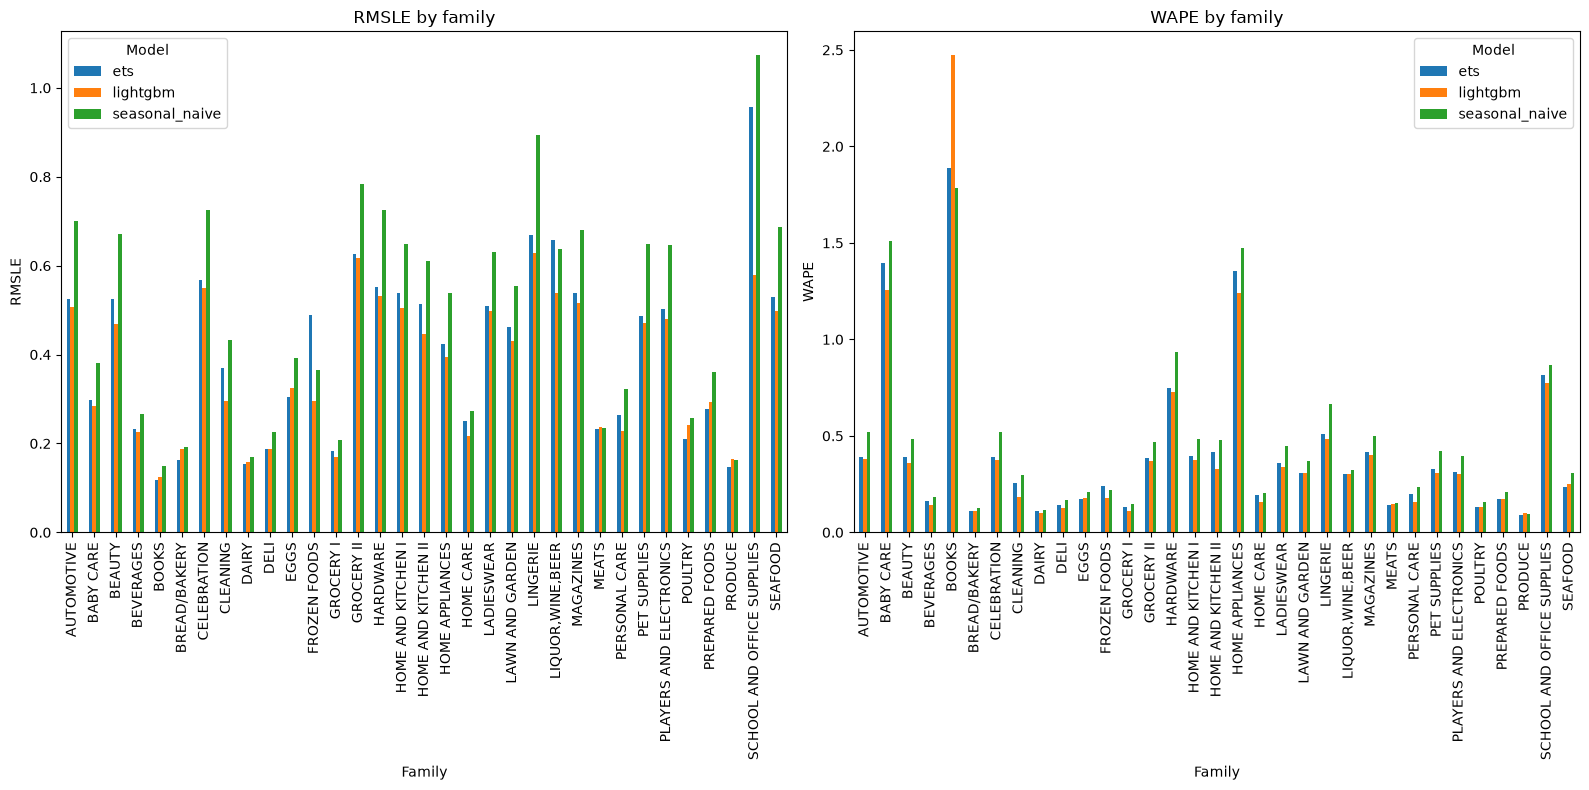

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16,8))
for ax, metric in zip(axes, ["RMSLE", "WAPE"]):
    pivot = (by_family).pivot(index="family", columns="model", values= metric)
    pivot.plot(kind="bar", stacked=False, ax=ax)
    ax.set_title(f"{metric} by family")
    ax.set_xlabel("Family")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=90)
    ax.legend(title="Model")

plt.tight_layout()
plt.show()

In [12]:
fam_stats = (train.groupby("family", observed=True)["sales"].agg(mean_sales="mean", cv=lambda s: s.std()/s.mean()).reset_index())

pivot = by_family.pivot(index="family", columns="model", values="RMSLE")
pivot["lgbm_minus_naive"] = pivot["lightgbm"] - pivot["seasonal_naive"]
fam_stats = fam_stats.merge(pivot["lgbm_minus_naive"].reset_index(), on="family")

print(fam_stats.sort_values("lgbm_minus_naive", ascending=False).round(3).to_string())

                        family   mean_sales     cv  lgbm_minus_naive
30                     PRODUCE  1349.352051  1.620             0.003
24                       MEATS   341.850006  1.334             0.002
5                 BREAD/BAKERY   463.335999  0.795            -0.004
8                        DAIRY   709.155029  0.948            -0.010
28                     POULTRY   350.532013  1.143            -0.016
4                        BOOKS     0.071000  7.740            -0.024
12                   GROCERY I  3776.971924  0.761            -0.038
9                         DELI   265.135010  0.794            -0.039
3                    BEVERAGES  2385.792969  0.967            -0.039
18                   HOME CARE   176.197998  1.191            -0.056
29              PREPARED FOODS    96.769997  1.082            -0.067
10                        EGGS   171.421005  0.944            -0.069
11                FROZEN FOODS   154.766998  2.100            -0.070
25               PERSONAL CARE   2

## Error Analysis and SHAP

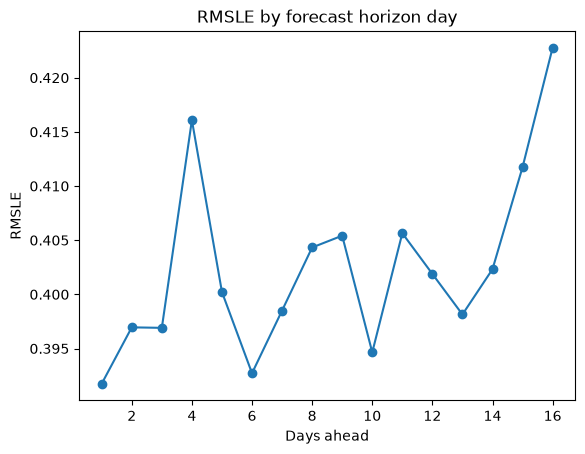

In [13]:
lgbm_preds["horizon_day"] = (
    lgbm_preds.groupby(["fold", "store_nbr", "family"], observed=True)["date"].rank(method="first").astype(int)
)

by_day = (lgbm_preds.groupby("horizon_day").apply(lambda g: rmsle(g.y_true, g.y_pred), include_groups=False))

by_day.plot(marker="o", title="RMSLE by forecast horizon day")
plt.xlabel("Days ahead")
plt.ylabel("RMSLE")
plt.show()

Mean residual: 3.631
Median residual: -0.025


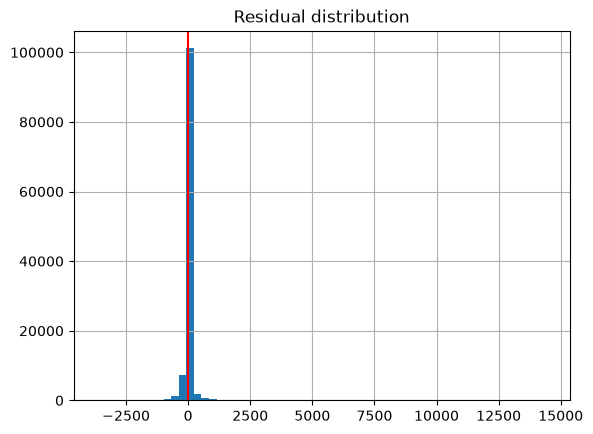

In [16]:
lgbm_preds["residual"] = lgbm_preds.y_true - lgbm_preds.y_pred
print("Mean residual:", lgbm_preds.residual.mean().round(3))
print("Median residual:", lgbm_preds.residual.median().round(3))

lgbm_preds["residual"].hist(bins=60)
plt.title("Residual distribution")
plt.axvline(0, color="red")
plt.show()

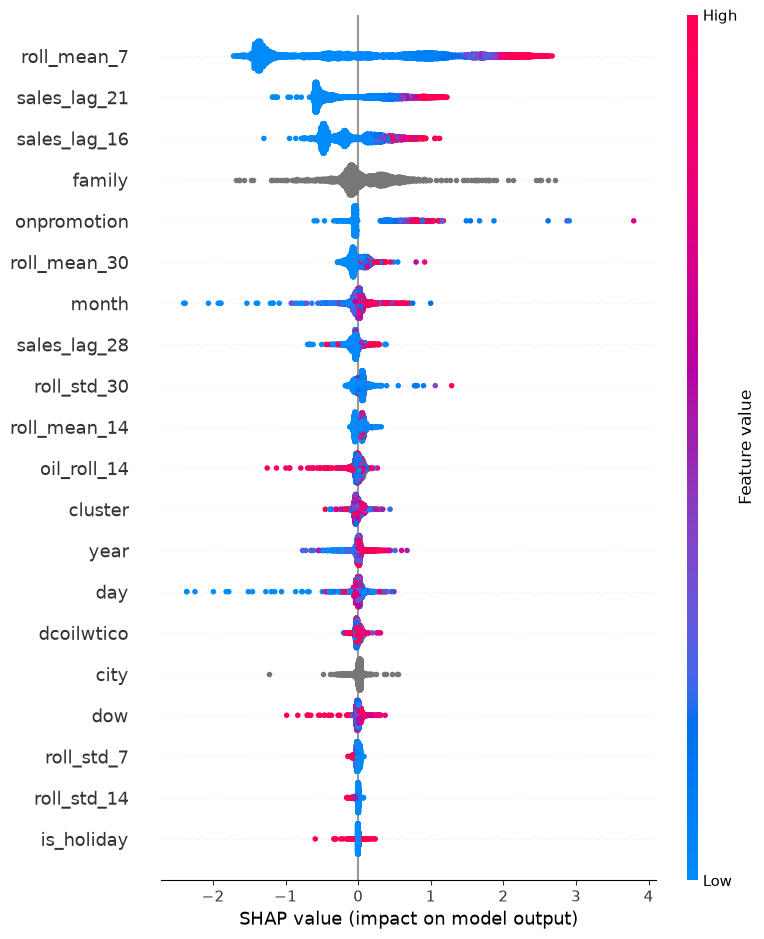

In [15]:
cutoff = feats["date"].max() - pd.Timedelta(days=16)
fit = feats[feats["date"] <= cutoff]

X = fit[feature_cols]
y = np.log1p(fit["sales"].clip(lower=0))
model = train_lgbm(X, y, categorical=CATEGORICAL, num_boost_round=300)

X_sample = X.sample(n=5000, random_state=1221)
explaier = shap.TreeExplainer(model)
shap_values = explaier.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, show=True)